In [27]:
# Import des bibliothèques essentielles pour le machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


<span style="color:#00008B;">

# 1 Classification #

We will use the dataset <b>"student_drop_out.csv"</b> that you can find here:

</span>

https://archive.ics.uci.edu/dataset/697

<span style="color:#00008B;">

Get familiar with the dataset. Each line correspond to a student with information at the time of enrollement in a high-education program.<br>
The label to predict is the "Target" attribute, being the status of the student at the time when he should finish his study program. There are three classes: "Dropout" (the student has dropped out), "Enrolled" (the student is still enrolled), and "Graduate" (the student has successfully finished his studies).

</span>

<span style="color:#00008B;">

## Question 1 ##
 
We will train a binary classification model, with class 0: "Droput" and class 1: "Enrolled" or "Graduate".  Load the datset into pandas DataFRame, and prepare it for classification.

</span>

In [ ]:
df = pd.read_csv('student_drop_out.csv', sep=';')


print(df['Target'].unique())
df = df.drop_duplicates()
# Créer les labels binaires : 0 = Dropout, 1 = Enrolled ou 
target_order = ["Dropout", "Enrolled", "Graduate"]
df["Target"] = df["Target"].apply(lambda x: 0 if x == "Dropout" else 1)


df

['Dropout' 'Graduate' 'Enrolled']


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,1
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,1


<span style="color:#00008B;">

## Question 2 ##

Visualise the data such that you can see if any features are redundant and the overall distribution  of the features within the two classes. You may need to normalise the values of each attribute. Interpret the results.

</span>

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

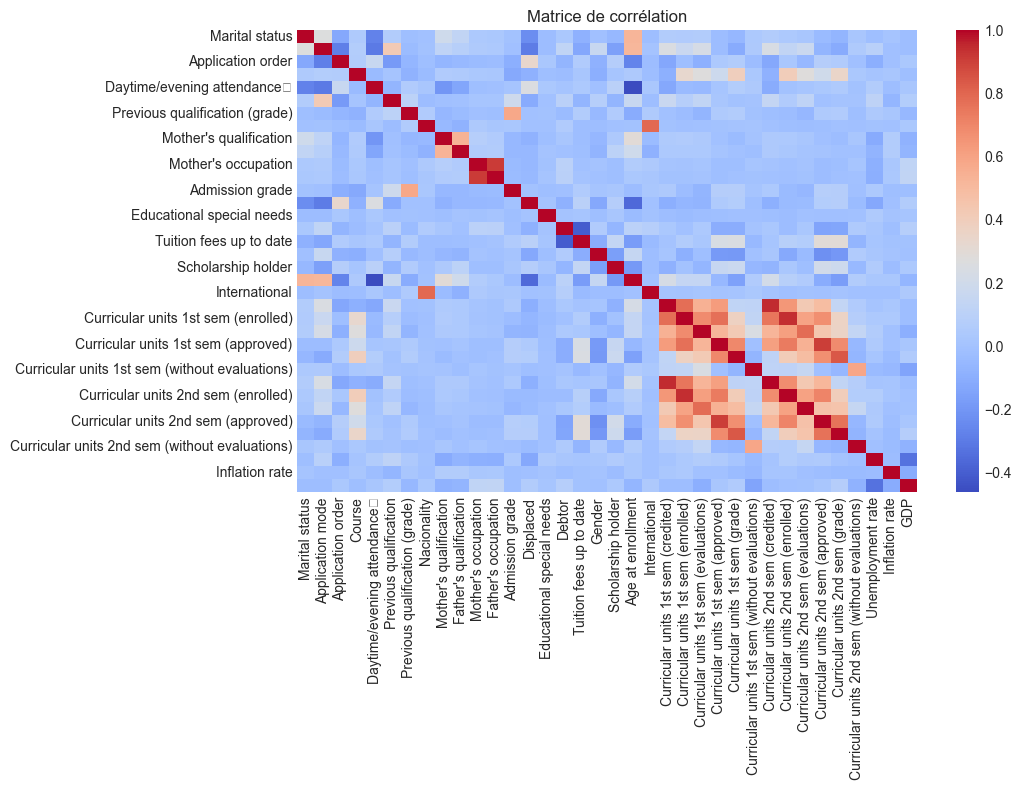

In [23]:
# Aperçu des données
print(df.head())
print(df.describe())

# Séparer les données
data = df.drop("Target", axis=1)
labels = df["Target"]

# Normalisation
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Recréer un DataFrame
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

# Matrice de corrélation
plt.figure(figsize=(10, 6))
corr = data_scaled.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Matrice de corrélation")

plt.show()

<span style="color:#00008B;">

### Interpretation: ###
</span>

Nous remarquons qu'aucunes caractéristiques ne sont suffisamment corélées pour pouvoir justifier leur suppression.

<span style="color:#00008B;">

## Question 3 ##
Split the dataset into a training  set (90%) and a test set (10%) and train a classifier using the algorithm of your choice. Calculate the classifiers accuracy on the trainning and test set.

Explain the algorithm. Where does the difference between the trainning and test accuracy come from?

</span>



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(data,labels, test_size=0.1,random_state=67)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

def Knn(seed):
    X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(data,labels, test_size=0.1,random_state=seed)


    # Create and train k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, Y_train)

    # Make predictions on training set
    y_train_pred = knn.predict(X_train)
    train_accuracy = (y_train_pred == Y_train).sum() / len(Y_train)

    # Make predictions on test set
    y_test_pred = knn.predict(X_test)
    test_accuracy = (y_test_pred == Y_test).sum() / len(Y_test)
    return test_accuracy

test_accuracy = Knn(42)
print(f"Test accuracy: {test_accuracy:.2f}%")
print(f"Actual values: {Y_test[:10]}")

Training set size: (3981, 36)
Test set size: (443, 36)
Test accuracy: 75.62%
Actual values: 3608    0
3165    1
1841    0
1879    1
1198    1
1004    0
1888    1
2022    0
1549    0
4249    1
Name: Target, dtype: int64


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def LogisticReg(seed):
    X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(data,labels, test_size=0.1,random_state=seed)

    # Create a pipeline with scaling and logistic regression
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, random_state=seed))
    ])

    # Train the model
    pipe_lr.fit(X_train, Y_train)

    # Make predictions
    y_test_pred_lr = pipe_lr.predict(X_test)

    # Evaluate accuracy
    from sklearn.metrics import accuracy_score
    accuracy_lr = accuracy_score(Y_test, y_test_pred_lr)

    return accuracy_lr


accuracy_lr = LogisticReg(42)

print(f"Logistic Regression Test Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"\nModel Comparison:")
print(f"Logistic Regression Accuracy: {accuracy_lr*100:.2f}%")

Logistic Regression Test Accuracy: 0.8736 (87.36%)

Model Comparison:
Logistic Regression Accuracy: 87.36%


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import sklearn.model_selection as ms


def Decision_Tree(seed):
    X_train, X_test, Y_train, Y_test = ms.train_test_split(
        data, labels, test_size=0.1, random_state=seed
    )

    dt = DecisionTreeClassifier(random_state=seed)
    dt.fit(X_train, Y_train)

    print(f"Tree depth: {dt.get_depth()}")
    print(f"Number of leaves: {dt.get_n_leaves()}")

    # Predictions
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(Y_train, train_pred)
    test_acc = accuracy_score(Y_test, test_pred)

    print("\n=== Performance ===")
    print(f"Train accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"Test accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")

    # Overfitting gap
    gap = train_acc - test_acc
    print(f"Overfitting gap: {gap:.4f}")

    # Cross-validation
    cv_scores = ms.cross_val_score(dt, data, labels, cv=5)
    print("\n=== Cross-validation ===")
    print(f"CV mean accuracy: {cv_scores.mean():.4f}")
    print(f"CV std: {cv_scores.std():.4f}")

    return test_acc


dt_accuracy = Decision_Tree(42)

print(
    f"\nDecision Tree Test Accuracy: {dt_accuracy:.4f} "
    f"({dt_accuracy*100:.2f}%)"
)

Decision Tree trained successfully
Tree depth: 21
Number of leaves: 448

=== Performance ===
Train accuracy: 1.0000 (100.00%)
Test accuracy:  0.8081 (80.81%)
Overfitting gap: 0.1919

=== Cross-validation ===
CV mean accuracy: 0.8013
CV std: 0.0069

Decision Tree Test Accuracy: 0.8081 (80.81%)


In [46]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def SVM(seed):
    X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(data,labels, test_size=0.1,random_state=seed)

    # Create a pipeline with scaling and SVM
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(max_iter=2000, random_state=seed))
    ])

    # Train the model
    pipe_svm.fit(X_train, Y_train)

    # Make predictions
    y_test_pred_svm = pipe_svm.predict(X_test)

    # Evaluate accuracy
    from sklearn.metrics import accuracy_score
    accuracy_svm = accuracy_score(Y_test, y_test_pred_svm)

    return accuracy_svm

accuracy_svm = SVM(42)

print(f"SVM Test Accuracy: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)")
print(f"\nModel Comparison Summary:")
print(f"SVM Accuracy: {accuracy_svm*100:.2f}%")

SVM Test Accuracy: 0.8826 (88.26%)

Model Comparison Summary:
SVM Accuracy: 88.26%


Sur le problème de prédiction du school dropout, on observe que les modèles SVM et régression logistique donnent les meilleurs résultats. Cela s’explique par leur capacité à bien séparer les classes (dropout vs non-dropout) grâce à des frontières de décision efficaces, tout en restant robustes et généralisant mieux que des modèles non-supervisés comme KNN, ou Desicion Tree qui manque de données et qui aurait tendance à se sur-spécialiser .

<span style="color:#00008B;">

## Question 4 ##

Change the random seed of the train/test split.<br>
Why is the result different? Do a more thorough evaluation aggreagating several different splits.

</span>


In [47]:
results = []
seeds = [42, 123, 456, 789, 999, 111, 222, 333]

knn_accuracy, svm_accuracy ,dt_accuracy, Lg_accuracy =0,0,0,0

for seed in seeds:
    knn_accuracy += Knn(seed)
    svm_accuracy += SVM(seed)
    dt_accuracy += Decision_Tree(seed)
    Lg_accuracy += LogisticReg(seed)

knn_accuracy = knn_accuracy/len(seeds)
svm_accuracy = svm_accuracy/len(seeds)
dt_accuracy = dt_accuracy/len(seeds)
Lg_accuracy = Lg_accuracy/len(seeds)

print(f"knn_accuracy: {knn_accuracy}")
print(f"svm_accuracy: {svm_accuracy}")
print(f"dt_accuracy: {dt_accuracy}")
print(f"Lg_accuracy: {Lg_accuracy}")


    
    


Decision Tree trained successfully
Tree depth: 21
Number of leaves: 448
Decision Tree trained successfully
Tree depth: 25
Number of leaves: 438
Decision Tree trained successfully
Tree depth: 27
Number of leaves: 469
Decision Tree trained successfully
Tree depth: 28
Number of leaves: 459
Decision Tree trained successfully
Tree depth: 26
Number of leaves: 462
Decision Tree trained successfully
Tree depth: 22
Number of leaves: 460
Decision Tree trained successfully
Tree depth: 25
Number of leaves: 458
Decision Tree trained successfully
Tree depth: 26
Number of leaves: 464
knn_accuracy: 76.07223476297969
svm_accuracy: 0.8786681715575619
dt_accuracy: 0.8185665914221221
Lg_accuracy: 0.8789503386004516


Les résultats varient quand la seed change car elle influence le découpage aléatoire des données (train/test). Même avec 4400 observations, la répartition des exemples — notamment des cas difficiles ou déséquilibrés (dropout vs non-dropout) — peut changer légèrement, ce qui impacte l’apprentissage du modèle et ses performances. Ainsi, certains splits peuvent être plus “favorables” que d’autres, d’où les variations observées.

Pour palier à cela, nous avons testé sur plusieurs seed, et calculé la moyenne, nous avons obtenu des résultats similaires.

<span style="color:#00008B;">

## Question 5 ##

Compute the confusion matrix on your test set predictions (normalising each row sum to 1), and explain it.<br>
What are the true/false positives (TP/FP) and true/false negatives (TN/FN)?<br>
Compute the F1 score. What is the advantage compared to the accuracy measure?

</span>

              precision    recall  f1-score   support

           0       0.87      0.78      0.82       143
           1       0.90      0.94      0.92       300

    accuracy                           0.89       443
   macro avg       0.88      0.86      0.87       443
weighted avg       0.89      0.89      0.89       443



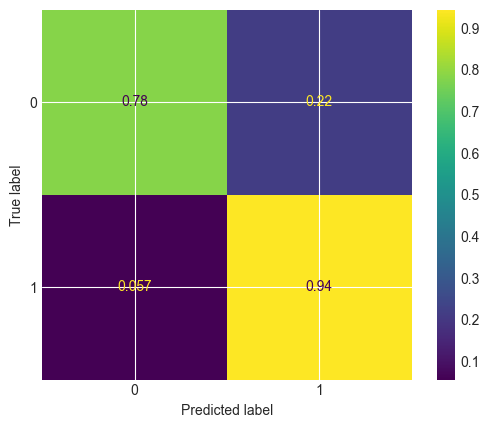

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(data,labels, test_size=0.1,random_state=seed)

# Create a pipeline with scaling and logistic regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=seed))
])

# Train the model
pipe_lr.fit(X_train, Y_train)

# Make predictions
y_test_pred_lr = pipe_lr.predict(X_test)

# Evaluate accuracy
from sklearn.metrics import accuracy_score
accuracy_lr = accuracy_score(Y_test, y_test_pred_lr)

print(classification_report(Y_test,y_test_pred_lr))

cm = confusion_matrix(Y_test,y_test_pred_lr)#, normalize="true")
cmd= ConfusionMatrixDisplay(cm)
cmd.plot()


<span style="color:#00008B;">

## Question 6 ##

Retrain your classifier with only 1% of the training set, and evaluate it on the same test set.<br> 
Why is the result worse? Can it be improved by decreasing the complexity of the classifier?

</span>

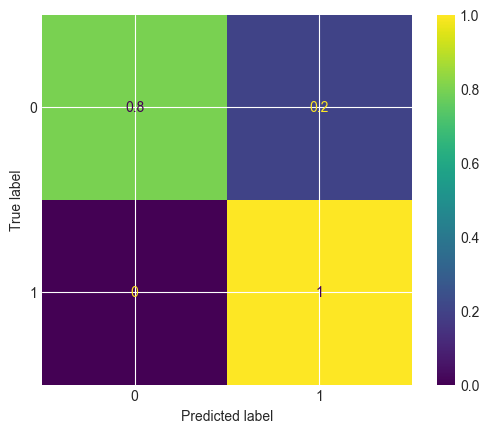

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(data,labels, test_size=0.01,random_state=seed)

# Create a pipeline with scaling and logistic regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=seed))
])

# Train the model
pipe_lr.fit(X_train, Y_train)

# Make predictions
y_test_pred_lr = pipe_lr.predict(X_test)

# Evaluate accuracy
from sklearn.metrics import accuracy_score
accuracy_lr = accuracy_score(Y_test, y_test_pred_lr)

cm = confusion_matrix(Y_test,y_test_pred_lr, normalize="true")
cmd= ConfusionMatrixDisplay(cm)
cmd.plot()


<span style="color:#00008B;">

# 2 Regresssion #

We will now use the dataset called <b>"measurements.csv"</b> that you can download from moodle.

It is composed of a two-dimensional data wich we will try to approximate via diffferent regression models.<br>
 We will minimise our empirical risk using the east Squares algorithm implemented  in the Linear Regression class of sklearn. 

</span>

<span style="color:#00008B;">

## Question 7 ##

Load the dataset (scatter plot). Then perform a linear regression using:<br>
<b><span style="color:#FFA05C;">sklearn.linear_model.LinearRegression. </span></b>

Compute the mean squared error and the R² score (coefficient of determination).<br>
Plot the estimated line together with the data points, and interpret the result.

</span>


<span style="color:#00008B;">

## Question 8 ##

We will now use the class PolynomialFeatures to do polynomialregression:<br>
<em><b><span style="color:#FFA05C"> from </span> <span style="color:#CD7DDE"> sklearn.preporcessing </span> <span style="color:#FFA05C"> import </span> <span style="color:#CD7DDE">  PolynomialFeatures </span></b></em>

Perform a series of polynomial regressions with increasing degrees, e.g 2, 8, 25. Compuute the corresponding MSE and R² abd plot the curves. <br>
Interpret the results. Why does Empirical Risk Minimisation fail when the hypothesis space is too large? <br>
<em>Useful functions to draw a polynomial with coeeficient in p (in order of decreasing degree):</em>
</span>
<br><br>
<span style="color:#57524C;">
x = np.linspace(0, 15, num=200)<br>
p = np.append(np.flip(poly_reg_model.coef_), (poly_reg_model.intercept_))<br>
y3 = np.polyval(p, x)
</span>
